# BaySeq

## Load and pre-process data

In [1]:
library(dplyr)
library(ggplot2)
library(tidyr)

# Load custom functions into pseudo-namespaces
bs <- new.env()
sys.source("scripts/BaySeq.R", envir = bs)
fn <- new.env()
sys.source("scripts/functions.R", envir = fn)

set.seed(123)

# Select data set
dataname <- "trauma"
dataname <- "Nurses"

#dataname <- "trauma_shuffled"
#dataname <- "Nurses_shuffled"

#dataname <- "sim-linear-1-out"

# Name of the column designating the center id
center_name <- "hospital"

# Only implemented for linear regression for now
use_local_intercepts <- TRUE

if (startsWith(dataname, "trauma")) {
        data(trauma, package = "BFI")
        data_raw <- trauma
} else if (startsWith(dataname, "Nurses")) {
        data(Nurses, package = "BFI")
        data_raw <- Nurses
} else {
        data_raw <- read.csv(paste0("data/raw/", dataname, ".csv"), row.names = 1)
}

# Shuffling center simulates homogeneous case
if (endsWith(dataname, "_shuffled")) {
        data_raw[[center_name]] <- sample(data_raw[[center_name]])
}

raw_dataname <- dataname
if (use_local_intercepts) {
    dataname <- paste0(dataname, "_", "local_int")
}

data_raw[[center_name]] <- factor(data_raw[[center_name]],
                        levels = sort(unique(data_raw[[center_name]]),
                        decreasing = FALSE))
dataname
head(data_raw)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: metadat

Loading required package: numDeriv


Loading the 'metafor' package (version 4.8-0). For an
introduction to the package please type: help(metafor)




[1] "Nurses_local_int"

hospital,nurse,age,gender,experien,stress,wardtype,hospsize
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,36,0,11,7,0,2
1,2,45,0,20,7,0,2
1,3,32,0,7,7,0,2
1,4,57,1,25,6,0,2
1,5,46,1,22,6,0,2
1,6,60,1,22,6,0,2


In [2]:
table(data_raw[[center_name]])
median(table(data_raw[[center_name]]))
sort(unique(data_raw[[center_name]]), decreasing = FALSE)


 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 
36 36 37 38 36 36 40 40 40 40 43 51 52 50 46 40 36 39 40 40 40 36 36 36 36 

[1] 40

[1] 1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
25 Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 25

In [3]:
scale_numeric_cols <- function(data) {
  data[] <- lapply(data, function(x) if (is.numeric(x)) scale(x)[, 1] else x)
  data
}

if (startsWith(dataname, "trauma")) {
    data_norm <- data_raw %>%
        # don't need to normalize within group as combined mean and sd can be computed without combining data
        mutate(
            age = scale(age),
            ISS = scale(ISS),
            GCS = scale(GCS)
        )

    model <- mortality ~ sex + age + ISS + GCS
    family <- "binomial" #(link = "logit")

} else if (startsWith(dataname, "Nurses")) {
    data_norm <- data_raw %>%
    mutate(
            age = scale(age),
            experience = scale(experien),
            stress = scale(stress),

            # keep numeric for now; fine if binary 0, 1
            #gender = factor(gender),
            #wardtype = factor(wardtype)
    )
    if (use_local_intercepts) {
        model_no_int <- as.formula(paste("stress ~ 0 + gender + age + experience +", center_name))
        model <- stress ~ gender + age + experience  # BFI paper leaves out wardtype
    } else {
        model <- stress ~ gender + age + experience + wardtype
    }
    family <- "gaussian"
} else if (startsWith(dataname, "sim-linear")) {
    data_norm <- scale_numeric_cols(data_raw)
    predictors <- setdiff(names(data_norm), c("y", "hospital"))
    if (use_local_intercepts) {
        model_no_int <- as.formula(paste("y ~ 0 +", paste(predictors, collapse = " + "), "+ hospital"))
        model <- as.formula(paste("y ~", paste(predictors, collapse = " + ")))
    } else {
        model <- as.formula(paste("y ~", paste(predictors, collapse = " + ")))
        m_brms <- as.formula(paste("y ~ 0 + Intercept +", paste(predictors, collapse = " + ")))
    }
    family <- "gaussian"
    family_alt <- family
} else {
  stop()
}

covariates <- attr(terms(model), "term.labels")
covariates_local <- covariates[covariates != center_name]
target <- all.vars(model)[1]

if (center_name %in% covariates) {
    data <- data_norm[c(target, covariates)]
} else {
    data <- data_norm[c(center_name, target, covariates)]
}

data_split <- data %>%
  group_by(.data[[center_name]]) %>%
  group_split()

n_centers <- length(data_split)
head(data_split[[1]])


if (use_local_intercepts) {
    p <- length(covariates) + n_centers
} else {
    p <- length(covariates)
}
p

hospital,stress,gender,age,experience
<fct>,"<dbl[,1]>",<dbl>,"<dbl[,1]>","<dbl[,1]>"
1,2.065329,0,-0.5817336,-1.0024484
1,2.065329,0,0.1656757,0.4870737
1,2.065329,0,-0.9139156,-1.6644582
1,1.044405,1,1.1622216,1.3145860
1,1.044405,1,0.2487212,0.8180786
1,1.044405,1,1.4113581,0.8180786


[1] 28

# Using Bayesian Sequential Updating

Equivalent to lm() on combined data, except for CI of sigma2. CI of betas must be computed using normal distribution, not marginal t-distribution.

In [4]:
bstats <- bs$bayseq_prepare(target, covariates, model, data_split, n_centers, use_local_intercepts, center_name)
params_seq <- bs$bayseq_oneshot(bstats, n_centers, use_local_intercepts, family,
                                covariates, epsilon = 1e-10, center_name, CI="normal",
                                return_post_params = TRUE)

df_seq <- bs$tidy_results(params_seq, use_local_intercepts)
df_seq["Covariate"][df_seq["Covariate"] == "Intercept"] <- "(Intercept)"
df_seq

[1] "Bayesian linear regression"


Method,Covariate,Estimate,lower,upper
<chr>,<chr>,<dbl>,<dbl>,<dbl>
BCA,gender,-0.4737137,-0.5867447,-0.3606827
BCA,age,0.2470454,0.1607654,0.3333255
BCA,experience,-0.3570065,-0.4434476,-0.2705654
BCA,sigma2,0.6317735,0.5791633,0.6919308


# Using Multivariate Meta-Analysis

In [5]:
# Fit local GLMs
res_local <- fn$fit_local_glms(data_split, model, target, covariates, center_name)
coef_list <- res_local$coef_list
se_list <- res_local$se_list
cov_list <- res_local$cov_list

In [6]:
# Meta-analyse GLM parameters
df_meta_mv_fe <- fn$fit_mv_meta_fixed(coef_list, cov_list)
df_meta_mv_reml <- fn$fit_mv_meta_random(coef_list, cov_list, method="REML")

# add simple mean of error variances
if (family == "gaussian") {
    sigma2 <- mean(res_local$sigma2_list)

    use_boot_CI <- FALSE
    if (use_boot_CI) {
        boot_means <- replicate(10000, mean(sample(res_local$sigma2_list, replace = TRUE)))
        ci <- quantile(boot_means, c(0.025, 0.975))
        lower <- ci[[1]]
        upper <- ci[[2]]
    } else {
        sigma2_sd <- sd(res_local$sigma2_list)
        n <- length(res_local$sigma2_list)
        error_margin <- qt(0.975, df = n - 1) * sigma2_sd / sqrt(n)
        lower <- sigma2 - error_margin
        upper <- sigma2 + error_margin
    }

    row <- list("sigma2", sigma2, lower, upper, "FE")
    df_sigma2 <- as.data.frame(row, stringsAsFactors = FALSE)
    colnames(df_sigma2) <- colnames(df_meta_mv_fe)
    df_meta_mv_fe <- rbind(df_meta_mv_fe, df_sigma2)

    row <- list("sigma2", sigma2, lower, upper, "REML")
    df_sigma2 <- as.data.frame(row, stringsAsFactors = FALSE)
    colnames(df_sigma2) <- colnames(df_meta_mv_fe)
    df_meta_mv_reml <- rbind(df_meta_mv_reml, df_sigma2)
}
df_meta_mv_fe
df_meta_mv_reml

Covariate,Estimate,lower,upper,Method
<chr>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),0.4761705,0.3941512,0.5581899,FE
gender,-0.4824995,-0.5783017,-0.3866972,FE
age,0.2643039,0.1915361,0.3370718,FE
experience,-0.3821681,-0.4554922,-0.3088439,FE
sigma2,0.6352886,0.4877670,0.7828101,FE


Covariate,Estimate,lower,upper,Method
<chr>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),0.4528117,0.3550594,0.5505641,REML
gender,-0.4983339,-0.6082770,-0.3883908,REML
age,0.2266000,0.1362747,0.3169252,REML
experience,-0.3869053,-0.4780777,-0.2957329,REML
sigma2,0.6352886,0.4877670,0.7828101,REML


# Using BFI

In [7]:
res_bfi_sub <- fn$bfi_sub(data_split, family, target, covariates, center_name)
df_bfi <- fn$fit_bfi(data_split, family, res_bfi_sub, use_local_intercepts)


Summary of the BFI model:

    Family: ‘gaussian’ 
      Link: ‘identity’

Coefficients:

                  Estimate Std.Dev CI 2.5% CI 97.5%
(Intercept)_loc1    0.6633  0.1590  0.3517   0.9748
(Intercept)_loc2    0.1958  0.0924  0.0147   0.3769
(Intercept)_loc3    0.2771  0.1652 -0.0466   0.6008
(Intercept)_loc4    0.6851  0.1065  0.4763   0.8939
(Intercept)_loc5    0.8734  0.0991  0.6791   1.0676
(Intercept)_loc6   -0.1097  0.1375 -0.3793   0.1598
(Intercept)_loc7    0.1014  0.0764 -0.0483   0.2511
(Intercept)_loc8    0.6104  0.0836  0.4465   0.7742
(Intercept)_loc9   -1.0940  0.1751 -1.4371  -0.7509
(Intercept)_loc10   0.8805  0.0934  0.6974   1.0637
(Intercept)_loc11   0.0587  0.1121 -0.1610   0.2784
(Intercept)_loc12   0.3139  0.1191  0.0805   0.5473
(Intercept)_loc13  -0.2119  0.1306 -0.4679   0.0441
(Intercept)_loc14  -0.2066  0.1082 -0.4186   0.0055
(Intercept)_loc15   0.6379  0.1364  0.3705   0.9053
(Intercept)_loc16   0.4868  0.1335  0.2252   0.7484
(Intercept)_loc17   0.259

# Using combined data (ground truth)

In [8]:
df_combined <- fn$fit_combined_glm(model, model_no_int, use_local_intercepts, center_name)

Waiting for profiling to be done...



# Compare methods

In [9]:
library(ggplot2)
library(ggpubr)
library(stringr)

method_order <- c("Combined", "BCA", "BFI", "FE", "REML")
df_merged <- rbind(df_combined, df_seq, df_bfi, df_meta_mv_fe, df_meta_mv_reml)  # must match above

if (use_local_intercepts) {
  df_merged <- df_merged %>%
    filter(
      Covariate != "(Intercept)",
      !str_starts(Covariate, "Intercept_")
    )
}

df_merged$Method <- factor(df_merged$Method, levels = method_order)
write.csv(df_merged, paste0("data/summarized/params.", dataname, ".csv"))

huemap <- setNames(get_palette(palette = "npg", length(levels(df_merged$Method))), levels(df_merged$Method))

Saving 7 x 7 in image


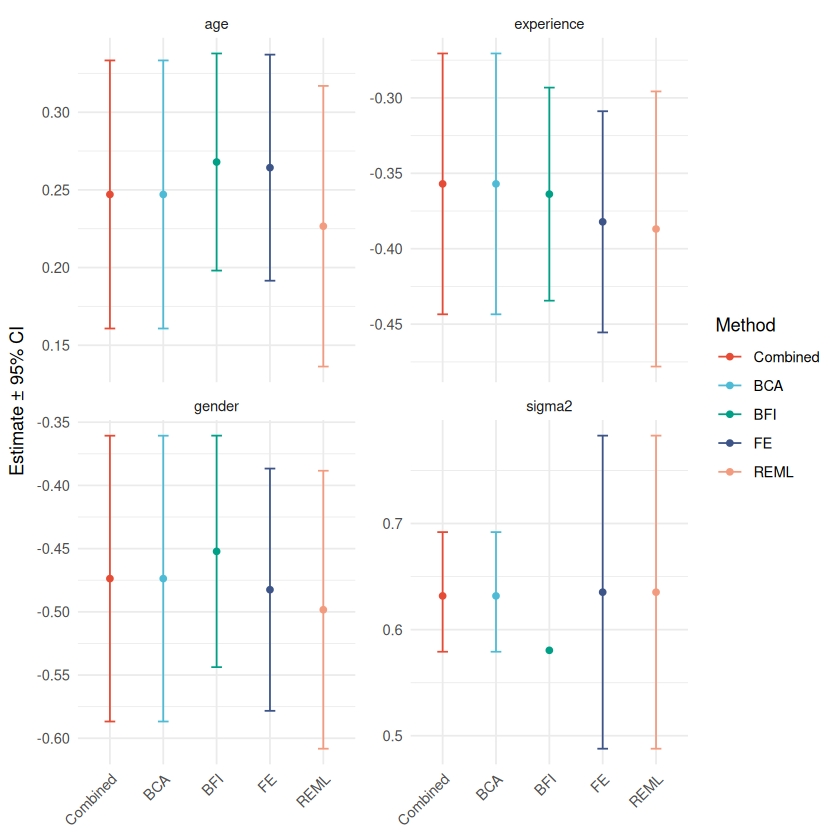

In [10]:
plot_params <- function(dataname, df_merged) {
  p <- ggplot(df_merged, aes(x = Method, y = Estimate, color = Method)) +
  geom_point(position = position_dodge(width = 0.5)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), 
                width = 0.2,
                position = position_dodge(width = 0.5)) +
  scale_color_manual(values = huemap) +
  facet_wrap(~ Covariate, scales = "free_y") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(y = "Estimate ± 95% CI", x = NULL)

  ggsave(paste0("figures_tmp/params.", dataname, ".png"), bg = "white")
  p
}

plot_params(dataname, df_merged)

# if (startsWith(dataname, "sim-")) {
#     simtruth <- read.csv(paste0("data/raw/", raw_dataname, ".truth.csv"))
#     simtruth
# }

# Reverse-Bayes

In [11]:
reduced_params <- NULL
if (family == "gaussian") {

    bayes_post_params <- params_seq$post_params

    for (l in seq_along(data_split)) {

        lambda_minus_l <- bayes_post_params$lambda_l - bstats[[l]]$xx
        a_minus_l <- bayes_post_params$a_l - bstats[[l]]$n
        mu_minus_l <- solve(lambda_minus_l) %*% (bayes_post_params$lambda_l %*% bayes_post_params$mu_l - bstats[[l]]$xy)
        mlm_full <- t(bayes_post_params$mu_l) %*% bayes_post_params$lambda_l %*% bayes_post_params$mu_l
        mlm_local <- t(mu_minus_l) %*% lambda_minus_l %*% mu_minus_l
        b_minus_l <- bayes_post_params$b_l + 0.5 * (mlm_full - mlm_local - bstats[[l]]$yy)
        beta_minus_l <- mu_minus_l
        reduced_params <- rbind(reduced_params, t(beta_minus_l))
    }

} else if (family == "binomial") {

    for (l in seq_along(data_split)) {
        delta_1s <- solve(params_seq$sigma)
        delta_l <- solve(bstats[[l]]$sigma)
        sigma_minus_l <- solve(delta_1s - delta_l)
        beta_minus_l <- sigma_minus_l %*% (delta_1s %*% params_seq$beta - delta_l %*% bstats[[l]]$beta)
        reduced_params <- rbind(reduced_params, t(beta_minus_l))
    }
}

reduced_params <- as.data.frame(reduced_params)
reduced_params$center <- seq_along(data_split)

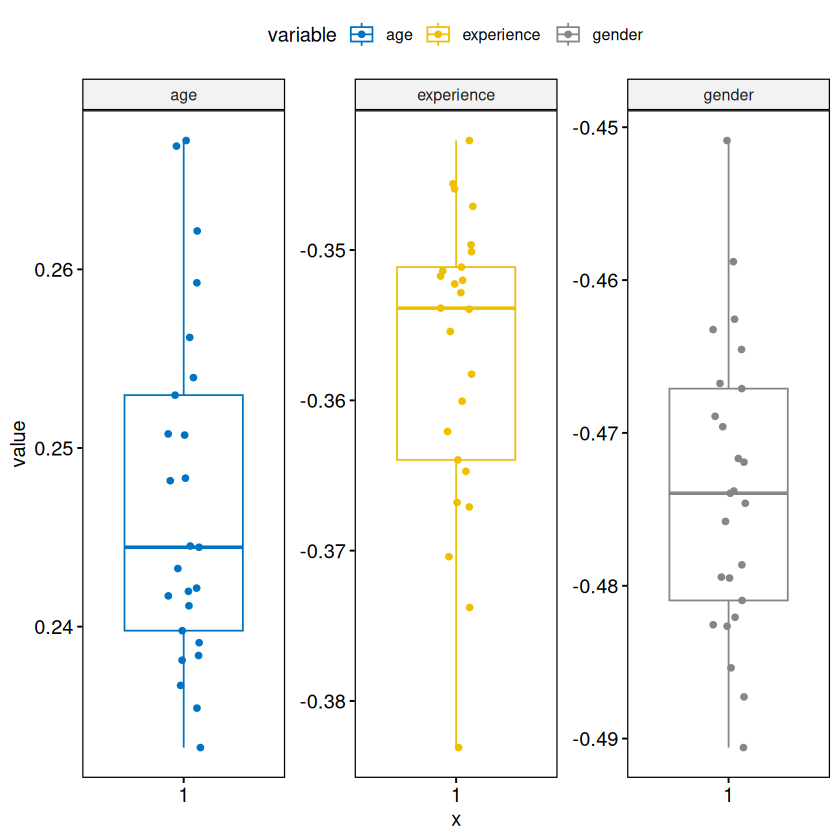

In [12]:
df_long <- reduced_params %>%
    pivot_longer(cols = -center, names_to = "variable", values_to = "value")

df_long <- df_long[!startsWith(df_long$variable, "Intercept_"), ]

p <- ggboxplot(
  df_long, 
  y = "value",
  color = "variable", 
  add = "jitter", 
  facet.by = "variable",
  palette = "jco"
)
p + facet_wrap(~variable, scales = "free_y")

In [13]:
stop()

ERROR: Error: 


# Normal-(inverse)-gamma

In [ ]:
covariates_local <- covariates[covariates != center_name]
prior_params <- bs$get_linreg_prior(covariates_local, use_local_intercepts, n_centers, epsilon=0)
bp <- bs$bayes_lin_reg_post_params(bstats, prior_params)
alpha <- bp$a_l
beta <- bp$b_l

In [ ]:
normal_gamma_plot <- function(bp, alpha, beta, covariates, covariate, use_local_intercepts, n_centers) {
    par(bg = "white")
    bp$mu_l[covariate, ]
    p <- length(covariates) + (if (use_local_intercepts) n_centers else 0)

    # Parameters for the Normal-Gamma
    mu0 <- bp$mu_l[covariate, ]
    lambda <- bp$lambda_l[covariate, covariate]
    alpha <- bp$a_l
    beta <- bp$b_l

    tau_l <- (alpha) / beta

    # Determine standard deviation of marginal mu (Student-t)
    df <- 2 * alpha
    scale2 <- beta / (lambda * alpha)
    sd_mu <- sqrt(as.vector(scale2 * df / (df - 2)))  # Only valid if df > 2

    # x-axis (mu): center around mu0, span ±4 SDs
    x_lim <- mu0 + c(-4, 4) * sd_mu

    # y-axis (tau): use quantiles of Gamma distribution
    y_lim <- qgamma(c(0.001, 0.999), shape = alpha, rate = beta)

    # Create grid of mu and tau values
    mu_vals <- seq(x_lim[[1]], x_lim[[2]], length.out = 200)
    tau_vals <- seq(y_lim[[1]], y_lim[[2]], length.out = 200)
    grid <- expand.grid(mu = mu_vals, tau = tau_vals)

    # Compute joint density of Normal-Gamma
    dnorm_gamma <- function(mu, tau, mu0, lambda, alpha, beta) {
        dnorm(mu, mean = mu0, sd = sqrt(1 / (lambda * tau))) *
        dgamma(tau, shape = alpha, rate = beta)
    }

    grid$z <- with(grid, dnorm_gamma(mu, tau, mu0, lambda, alpha, beta))
    z_matrix <- matrix(grid$z, nrow = length(mu_vals), ncol = length(tau_vals))

    contour(mu_vals, tau_vals, z_matrix,
            xlab = expression(mu), ylab = expression(tau),
            main = "Normal-Gamma Joint Density Contour")

    abline(v = mu0, col = "blue", lty = 2, lwd = 2)
    abline(h = tau_l, col = "blue", lty = 2, lwd = 2)


    ##### Plot marginals ####

    ### Marginal for mu: Student-t ###
    df <- 2 * alpha
    scale2 <- beta / (lambda * alpha)
    s <- sqrt(as.vector(scale2))
    curve(dt((x - mu0) / s, df = df) / s,
        from = x_lim[[1]], to = x_lim[[2]], col = "blue", lwd = 2,
        main = "Marginal of mu (Student-t)", ylab = "Density", xlab = expression(mu))

    abline(v = mu0, col = "blue", lty = 2, lwd = 2)

    ### Marginal for tau: Gamma ###
    # Plot the Gamma density
    curve(dgamma(x, shape = alpha, rate = beta),
        from = y_lim[[1]], to = y_lim[[2]], col = "red", lwd = 2,
        main = "Marginal of tau (Gamma)", ylab = "Density", xlab = expression(tau))

    abline(v = tau_l, col = "blue", lty = 2, lwd = 2)
    legend("topleft",
        legend = c("tau_l"),
        col = c("blue"),
        lty = c(2, 3),
        lwd = 2,
        bty = "n")
}

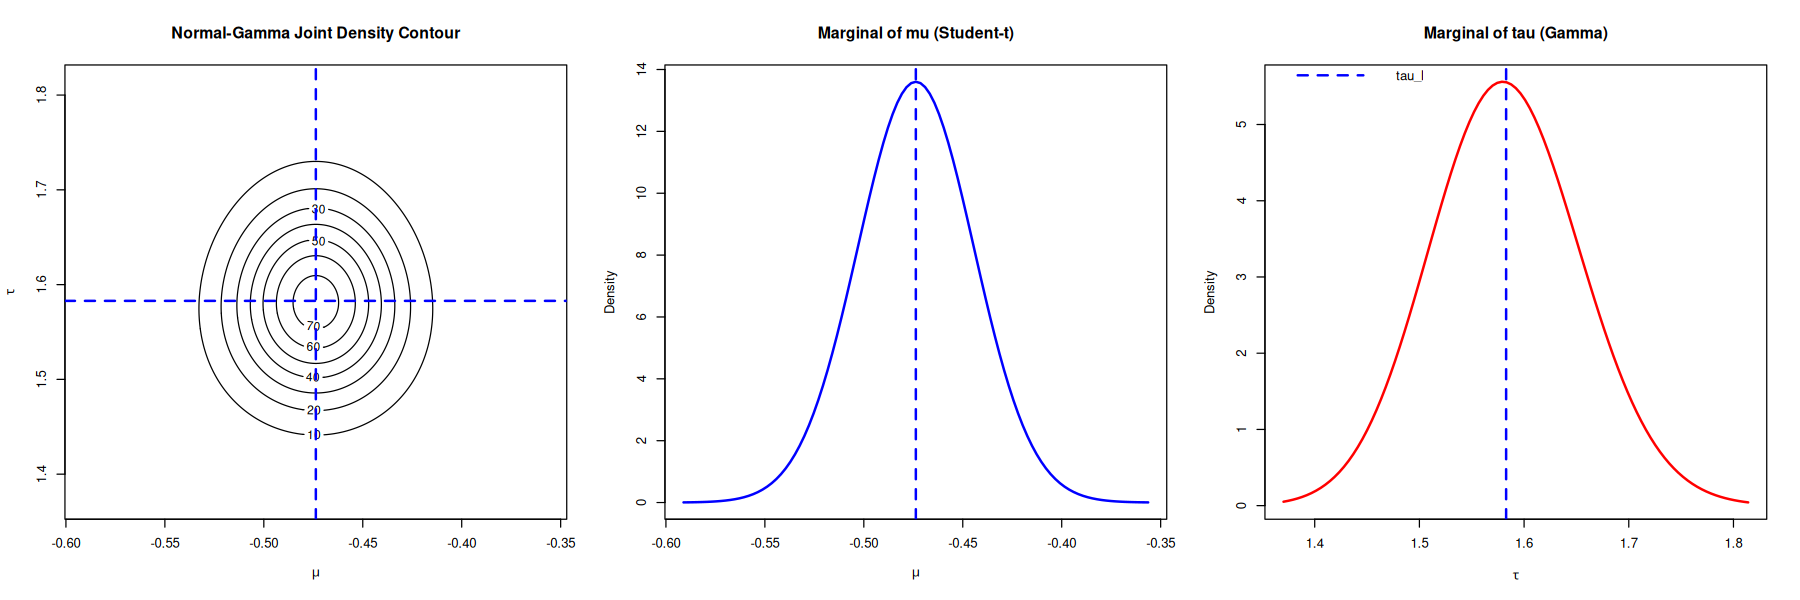

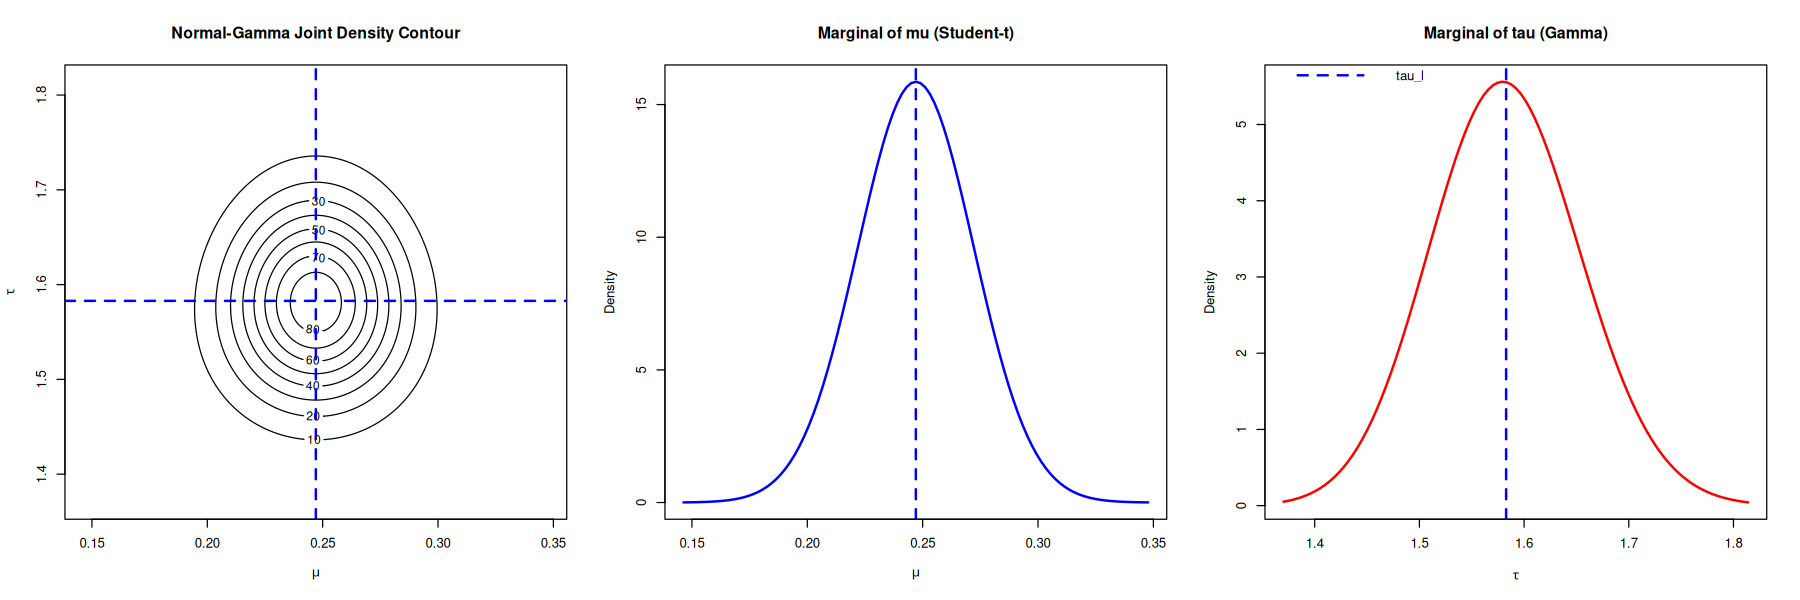

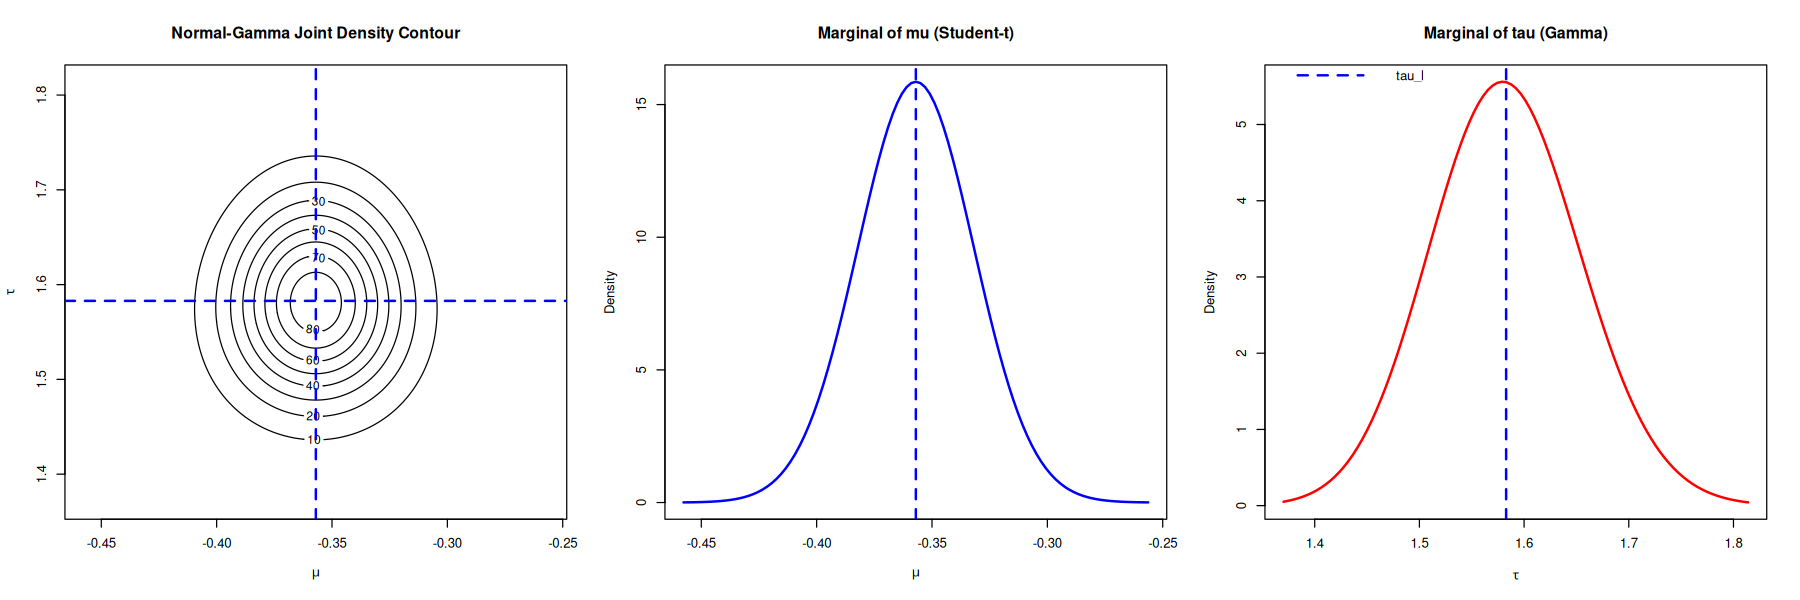

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 5)
#par(mfrow = c(2, 3), bg = "white")
par(mfrow = c(1, 3), bg = "white")

normal_gamma_plot(bp, alpha, beta, covariates, "gender", use_local_intercepts, n_centers)
normal_gamma_plot(bp, alpha, beta, covariates, "age", use_local_intercepts, n_centers)
normal_gamma_plot(bp, alpha, beta, covariates, "experience", use_local_intercepts, n_centers)

In [ ]:
normal_inv_gamma_plot <- function(bp, alpha, beta, covariates, covariate, use_local_intercepts, n_centers) {

    mu0 <- bp$mu_l[covariate, ]
    lambda <- bp$lambda_l[covariate, covariate]
    alpha <- as.vector(bp$a_l)
    beta <- as.vector(bp$b_l)

    p <- length(covariates) + (if (use_local_intercepts) n_centers else 0)
    tau_l <- (alpha) / beta
    sigma2_l <- 1/tau_l

    # Determine standard deviation of marginal mu (Student-t)
    df <- 2 * alpha
    scale2 <- beta / (lambda * alpha)
    sd_mu <- as.vector(sqrt(scale2 * df / (df - 2)))  # Only valid if df > 2

    # x-axis (mu): center around mu0, span ±4 SDs
    x_lim <- mu0 + c(-4, 4) * sd_mu

    # y-axis (tau): use quantiles of Gamma distribution
    qinvgamma <- function(p, shape, rate) {
        1 / qgamma(1 - p, shape = shape, rate = rate)
    }
    y_lim <- qinvgamma(c(0.001, 0.999), shape = alpha, rate = beta)

    # Create grid of mu and tau values
    mu_vals <- seq(x_lim[[1]], x_lim[[2]], length.out = 200)
    tau_vals <- seq(y_lim[[1]], y_lim[[2]], length.out = 200)
    grid <- expand.grid(mu = mu_vals, tau = tau_vals)

    dinv_gamma <- function(sigma2, alpha, beta) {
        log_density <- alpha * log(beta) - lgamma(alpha) - (alpha + 1) * log(sigma2) - beta / sigma2
        exp(log_density)
    }
    dnorm_inv_gamma <- function(mu, sigma2, mu0, lambda, alpha, beta) {
        s <- sqrt(sigma2 / lambda)
        dnorm(mu, mean = mu0, sd = s) * dinv_gamma(sigma2, alpha, beta)
    }


    grid$z <- with(grid, dnorm_inv_gamma(mu, tau, mu0, lambda, alpha, beta))
    z_matrix <- matrix(grid$z, nrow = length(mu_vals), ncol = length(tau_vals))

    contour(mu_vals, tau_vals, z_matrix,
            xlab = expression(mu), ylab = "sigma",
            main = "Normal-Inverse-Gamma Joint Density Contour")

    abline(v = mu0, col = "blue", lty = 2, lwd = 2)
    abline(h = sigma2_l, col = "blue", lty = 2, lwd = 2)


    ##### Plot marginals ####

    ### Marginal for mu: Student-t ###
    df <- 2 * alpha
    scale2 <- beta / (lambda * alpha)
    curve(dt((x - mu0) / sqrt(scale2), df = df) / sqrt(scale2),
        from = x_lim[[1]], to = x_lim[[2]], col = "blue", lwd = 2,
        main = "Marginal of mu (Student-t)", ylab = "Density", xlab = expression(mu))

    abline(v = mu0, col = "blue", lty = 2, lwd = 2)

    ### Marginal for sigma2: Inverse-Gamma ###
    curve(dinv_gamma(x, alpha, beta),
        from = y_lim[[1]], to = y_lim[[2]], col = "red", lwd = 2,
        main = "Marginal of sigma2 (Inverse-Gamma)", ylab = "Density", xlab = "sigma2")

    abline(v = sigma2_l, col = "blue", lty = 2, lwd = 2)

    legend("topleft",
        legend = c("sigma2_l"),
        col = c("blue"),
        lty = c(2, 3),
        lwd = 2,
        bty = "n")
}

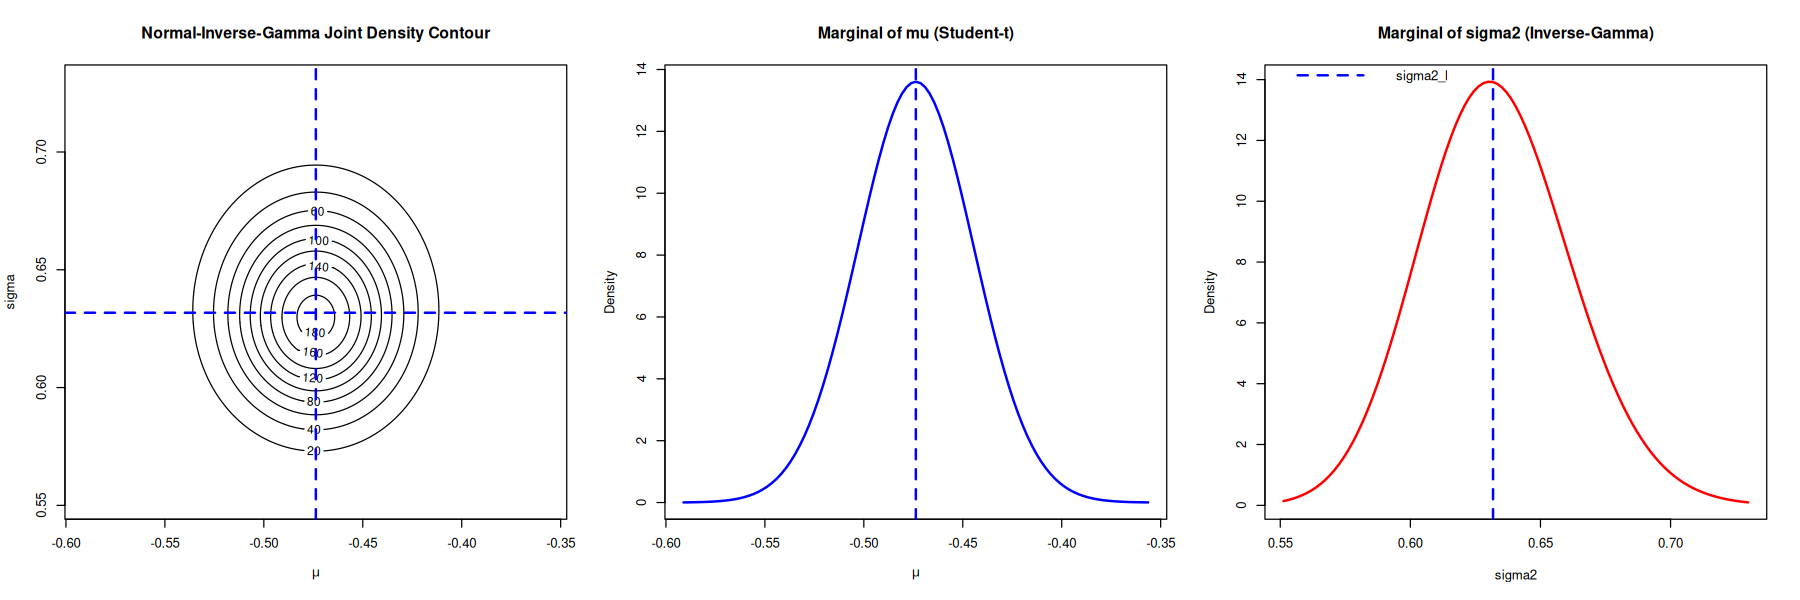

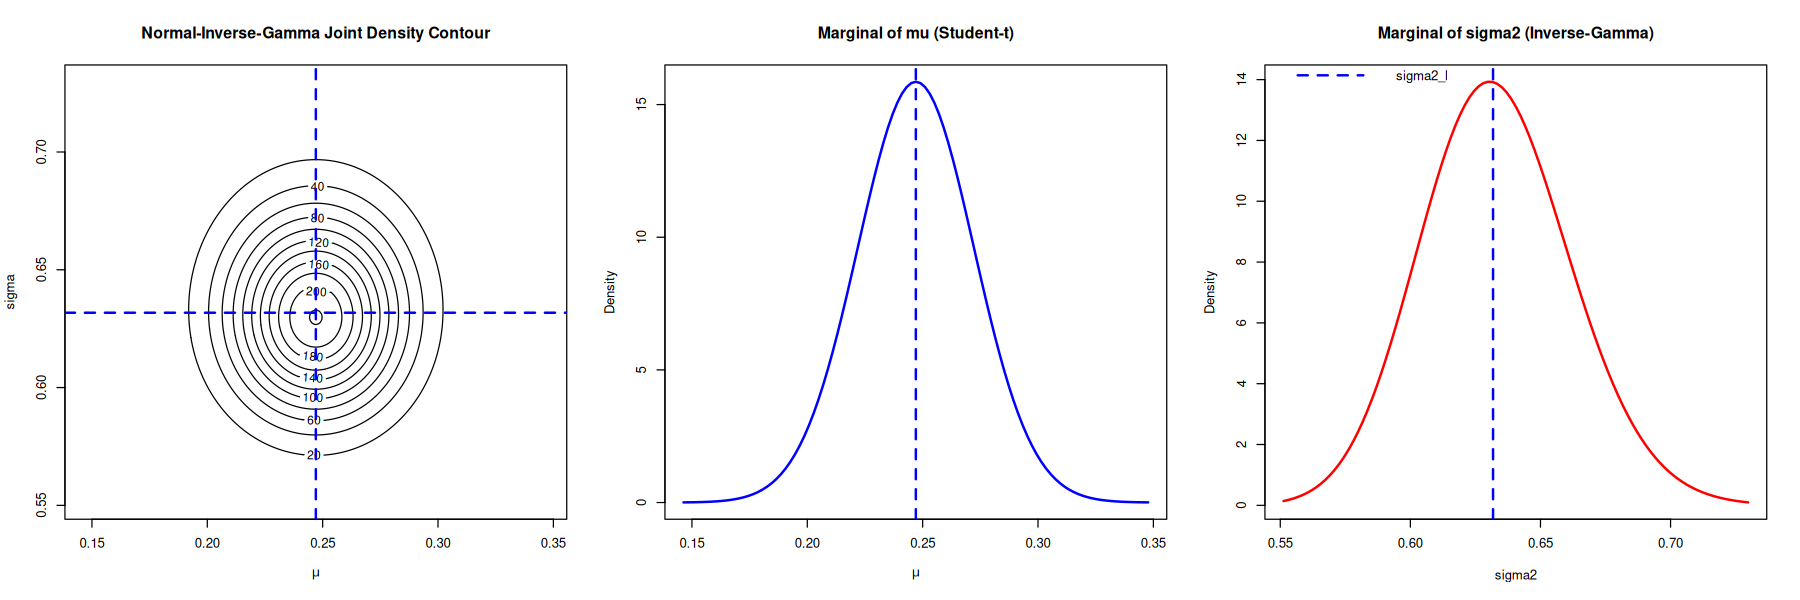

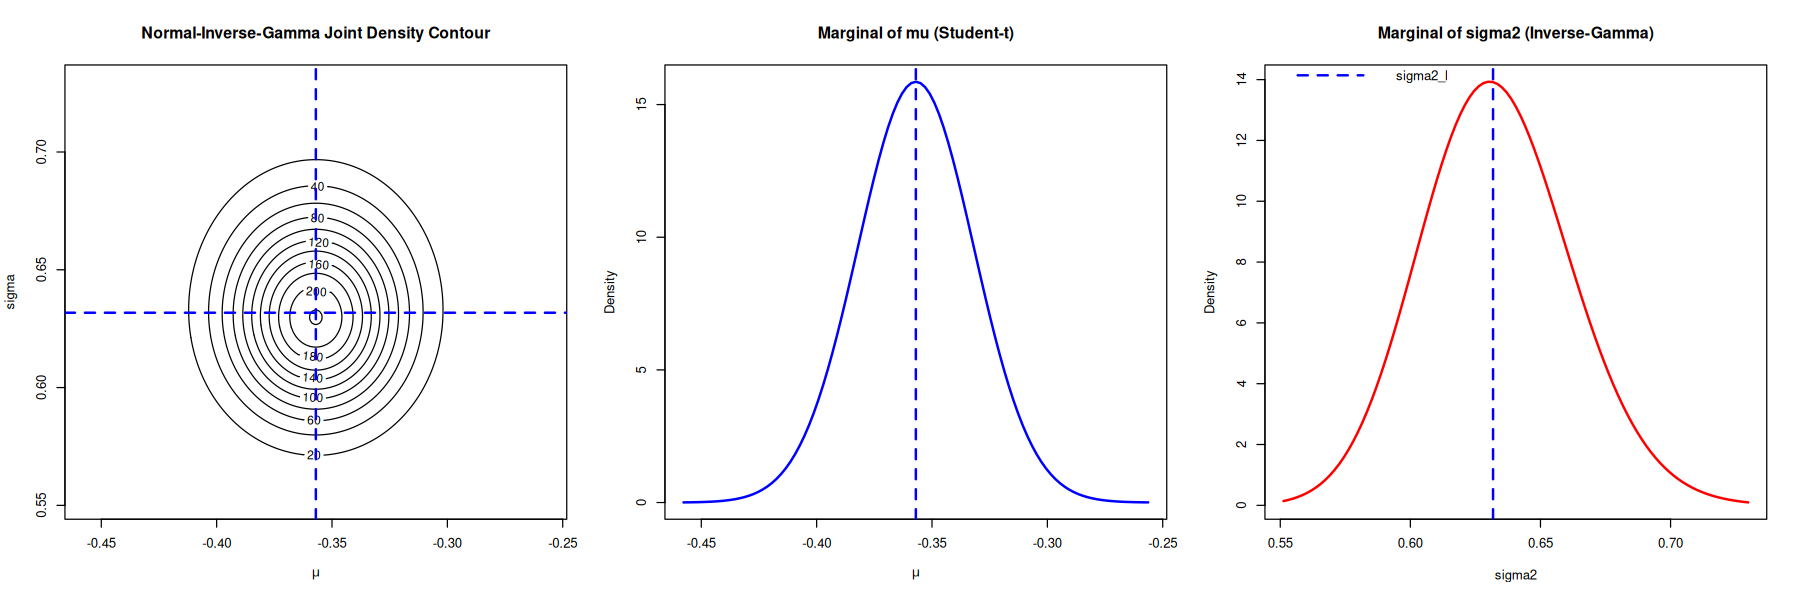

In [ ]:
options(repr.plot.width = 15, repr.plot.height = 5)
par(mfrow = c(1, 3), bg = "white")

normal_inv_gamma_plot(bp, alpha, beta, covariates, "gender", use_local_intercepts, n_centers)
normal_inv_gamma_plot(bp, alpha, beta, covariates, "age", use_local_intercepts, n_centers)
normal_inv_gamma_plot(bp, alpha, beta, covariates, "experience", use_local_intercepts, n_centers)

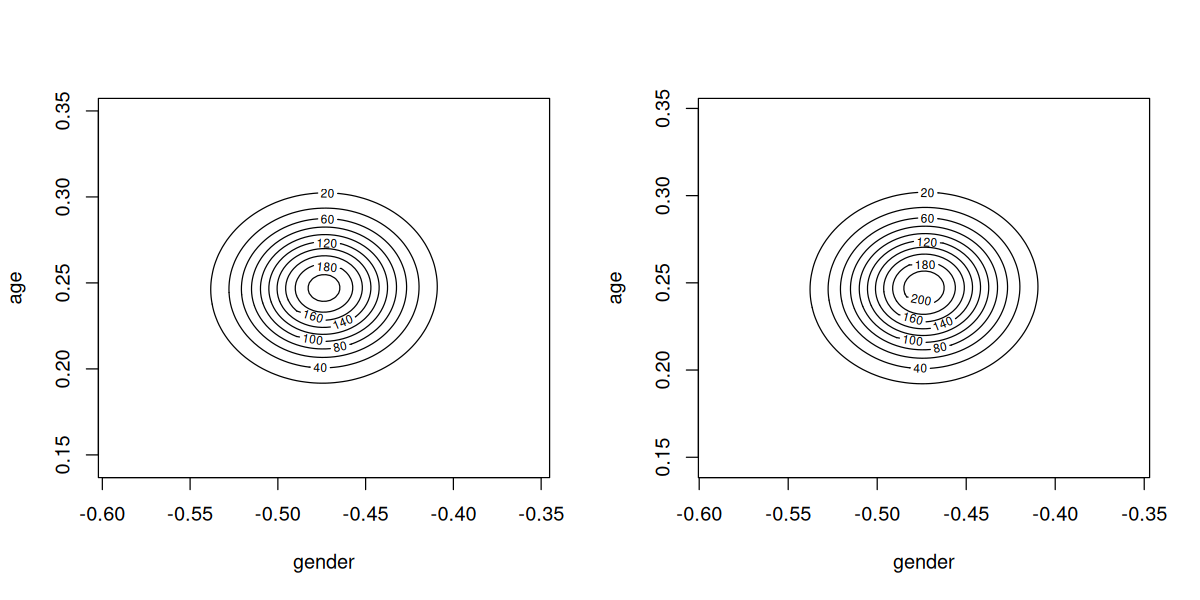

In [ ]:
library(mvtnorm)
options(repr.plot.width = 10, repr.plot.height = 5)
par(mfrow = c(1, 2), bg = "white")

covariate1 <- "gender"
covariate2 <- "age"

alpha <- bp$a_l
beta <- bp$b_l
tau_l <- (alpha - p/2) / beta
tau_mode_uv_joint <- (alpha - 1/2) / beta

plot_mvn <- function(bp, covariate1, covariate2, tau) {

    lambda_12 <- bp$lambda_l[c(covariate1, covariate2), c(covariate1, covariate2)]
    mu1 <- bp$mu_l[covariate1, ]
    mu2 <- bp$mu_l[covariate2, ]

    mu <- c(mu1, mu2)
    Sigma <- solve(as.numeric(tau) * lambda_12)
    x_lim <- mu1 + c(-4, 4) * sqrt(Sigma[1, 1])
    y_lim <- mu2 + c(-4, 4) * sqrt(Sigma[2, 2])

    x <- seq(x_lim[[1]], x_lim[[2]], length.out = 100)
    y <- seq(y_lim[[1]], y_lim[[2]], length.out = 100)
    grid <- expand.grid(x = x, y = y)
    z <- matrix(dmvnorm(grid, mean = mu, sigma = Sigma), nrow = 100)

    contour(x, y, z, xlab = covariate1, ylab = covariate2)
}


plot_mvn(bp, covariate1, covariate2, tau_l)
plot_mvn(bp, covariate1, covariate2, tau_mode_uv_joint)

 # SessionInfo

In [ ]:
sink("session_info.txt")
print(sessionInfo())
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 24.04.2 LTS

Matrix products: default
BLAS/LAPACK: /home/pedege/miniforge3/envs/pydata/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Zurich
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] mvtnorm_1.3-3       stringr_1.5.1       ggpubr_0.6.1       
 [4] BFI_3.1.0           metafor_4.8-0       numDeriv_2016.8-1.1
 [7] metadat_1.4-0       Matrix_1.6-5        invgamma_1.2       
[10] tidyr_1.3.1         ggpl

# To do

- use reference posterior t-distr for CIs? Bernardo-Smith p. 442